In [1]:
# импорт библиотек
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(style="ticks")

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
# загрузка данных
data = pd.read_csv('hotel_bookings.csv')

In [3]:
data.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
data.shape

(119390, 32)

In [5]:
data.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [6]:
data.dtypes

,0
hotel,object
is_canceled,int64
lead_time,int64
arrival_date_year,int64
arrival_date_month,object
arrival_date_week_number,int64
arrival_date_day_of_month,int64
stays_in_weekend_nights,int64
stays_in_week_nights,int64
adults,int64


In [7]:
data.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [8]:
# обработка пропусков
data_clean = data.drop(columns=['agent', 'company'])
data_clean['children'] = data_clean['children'].fillna(0)
data_clean['country'] = data_clean['country'].fillna(data_clean['country'].mode()[0])

In [9]:
# создание новых признаков
data_clean['total_people'] = data_clean['adults'] + data_clean['children'] + data_clean['babies']
data_clean = data_clean[data_clean['total_people'] > 0]

In [10]:
month_order = {
    'January':1, 'February':2, 'March':3, 'April':4, 'May':5, 'June':6,
    'July':7, 'August':8, 'September':9, 'October':10, 'November':11, 'December':12
}
data_clean['month'] = data_clean['arrival_date_month'].map(month_order)

In [11]:
data_clean.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,total_people,month
count,119210.000000,119210.000000,119210.000000,119210.000000,119210.000000,119210.000000,119210.000000,119210.000000,119210.000000,119210.000000,119210.000000,119210.000000,119210.000000,119210.000000,119210.000000,119210.000000,119210.000000,119210.000000,119210.000000,119210.000000
mean,0.370766,104.109227,2016.156472,27.163376,15.798717,0.927053,2.499195,1.859206,0.104043,0.007961,0.031499,0.087191,0.137094,0.218799,2.321215,101.969092,0.062553,0.571504,1.971210,6.552051
std,0.483012,106.875450,0.707485,13.601107,8.781070,0.995117,1.897106,0.575186,0.398836,0.097509,0.174663,0.844918,1.498137,0.638504,17.598002,50.434007,0.245360,0.792876,0.718876,3.089796
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000,1.000000,1.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,69.500000,0.000000,0.000000,2.000000,4.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,94.950000,0.000000,0.000000,2.000000,7.000000
75%,1.000000,161.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,126.000000,0.000000,1.000000,2.000000,9.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,18.000000,391.000000,5400.000000,8.000000,5.000000,55.000000,12.000000


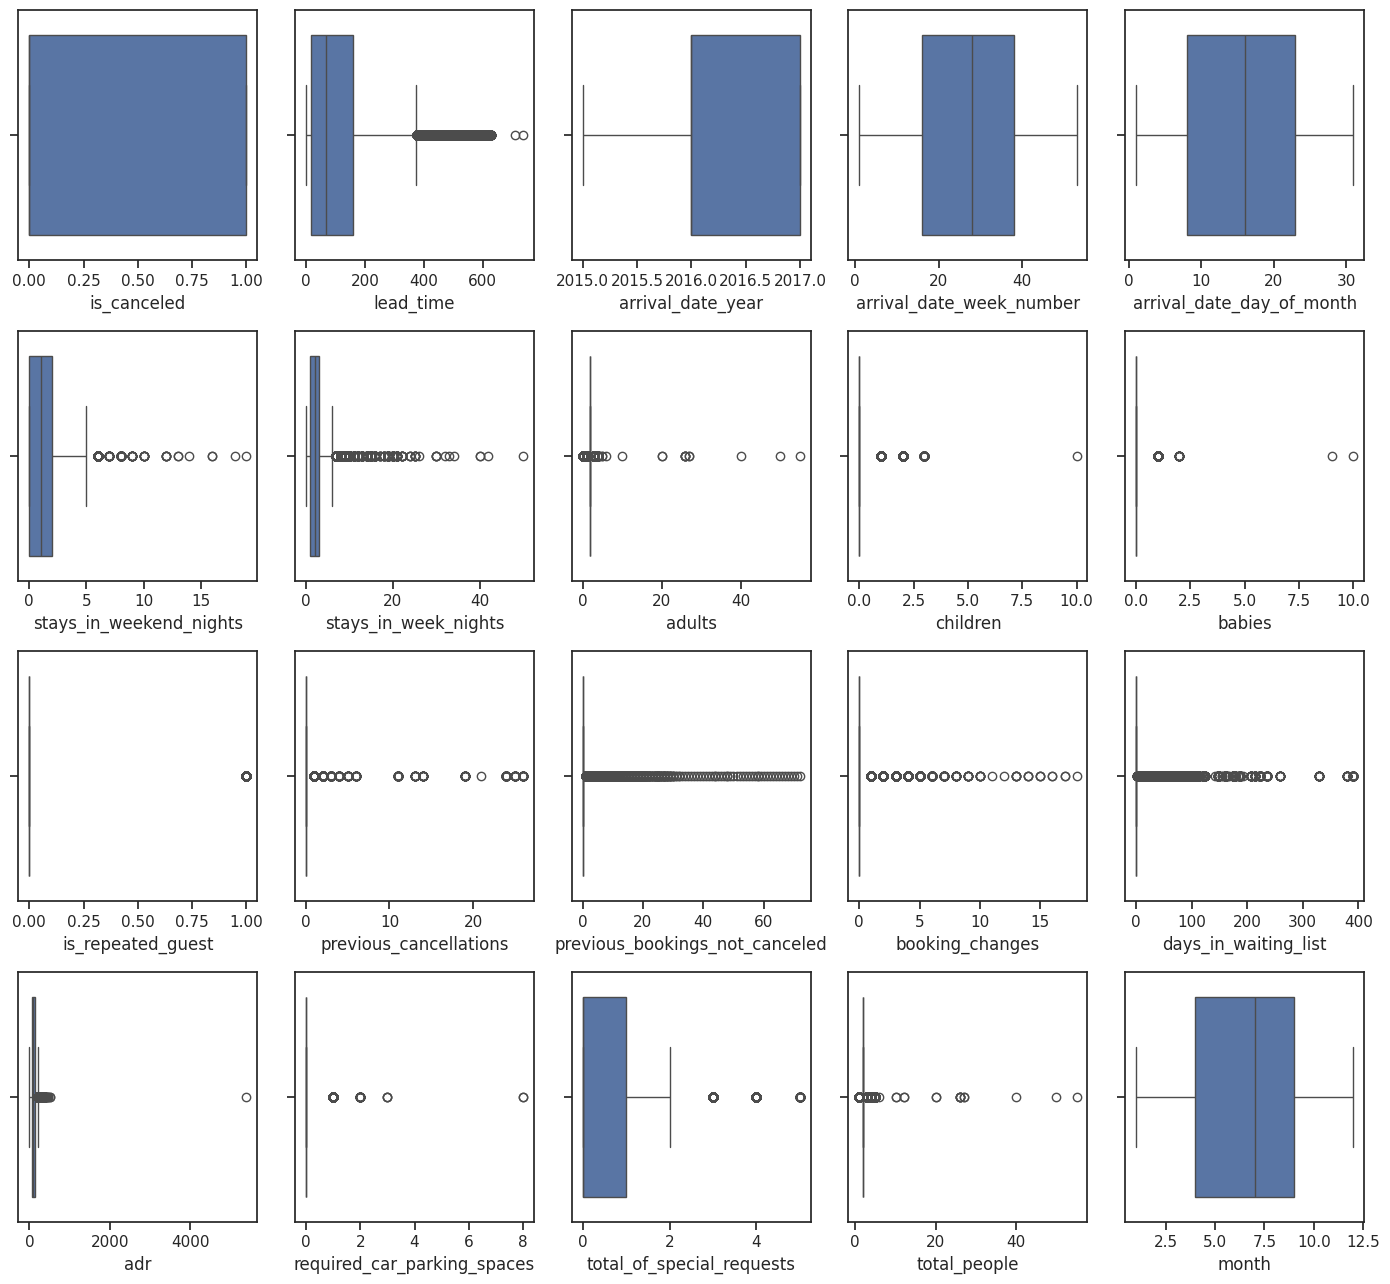

In [12]:
numeric_cols = data_clean.select_dtypes(include=['int64', 'float64']).columns

fig, axes = plt.subplots(4, 5, figsize=(14, 13))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=data_clean[col], ax=axes[i])

plt.tight_layout()
plt.show()

In [13]:
# удаление выбросов
data_clean = data_clean[data_clean['adr'] <= data_clean['adr'].quantile(0.99)]
data_clean = data_clean[data_clean['total_people'] <= data_clean['total_people'].quantile(0.99)]

print(f"После удаления выбросов: {len(data_clean)} строк")

После удаления выбросов: 117940 строк


In [14]:
data_clean['is_canceled'].value_counts()

,count
is_canceled,
0,74205
1,43735


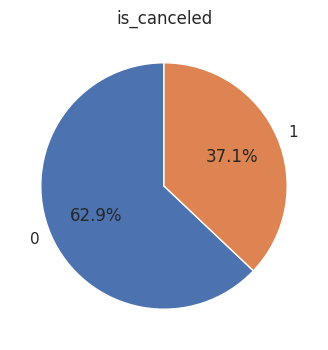

In [15]:
# визуализация рапределения классов целевой переменной
plt.figure(figsize=(4, 4))
plt.pie(data_clean['is_canceled'].value_counts(), labels=['0', '1'], autopct='%1.1f%%', startangle=90)
plt.title('is_canceled')
plt.show()

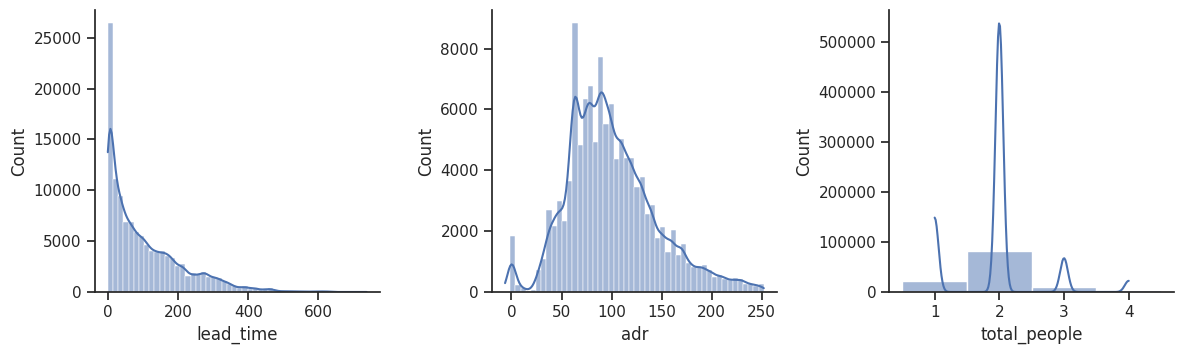

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.7))
sns.histplot(data_clean['lead_time'], bins=50, kde=True, ax=axes[0])
sns.histplot(data_clean['adr'], bins=50, kde=True, ax=axes[1])
sns.histplot(data_clean['total_people'], bins=range(1, 21), discrete=True, kde=True, ax=axes[2])
sns.despine()
plt.tight_layout()
plt.show()

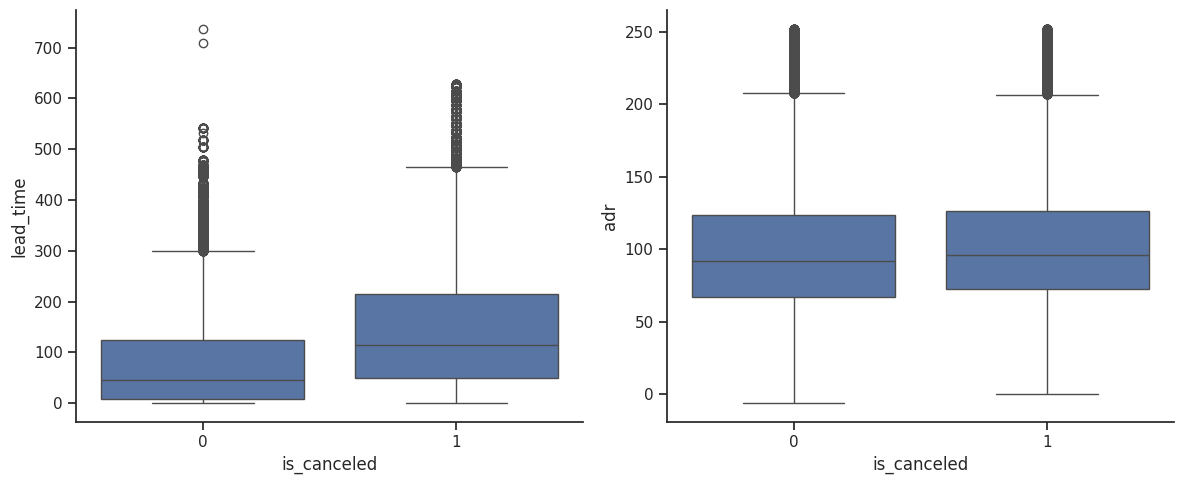

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(x='is_canceled', y='lead_time', data=data_clean, ax=axes[0])
sns.boxplot(x='is_canceled', y='adr', data=data_clean, ax=axes[1])

sns.despine()
plt.tight_layout()
plt.show()

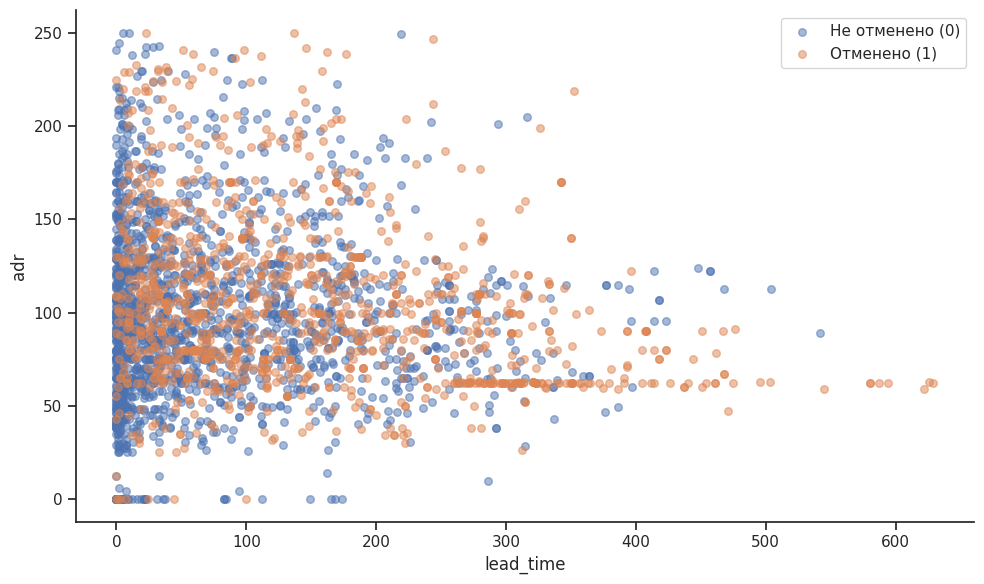

In [18]:
plt.figure(figsize=(10, 6))

sample = data_clean.sample(n=3000, random_state=42)

not_canceled = sample[sample['is_canceled'] == 0]
canceled = sample[sample['is_canceled'] == 1]

plt.scatter(not_canceled['lead_time'], not_canceled['adr'],
            label='Не отменено (0)', alpha=0.5, s=30)
plt.scatter(canceled['lead_time'], canceled['adr'],
            label='Отменено (1)', alpha=0.5, s=30)

plt.xlabel('lead_time', fontsize=12)
plt.ylabel('adr', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

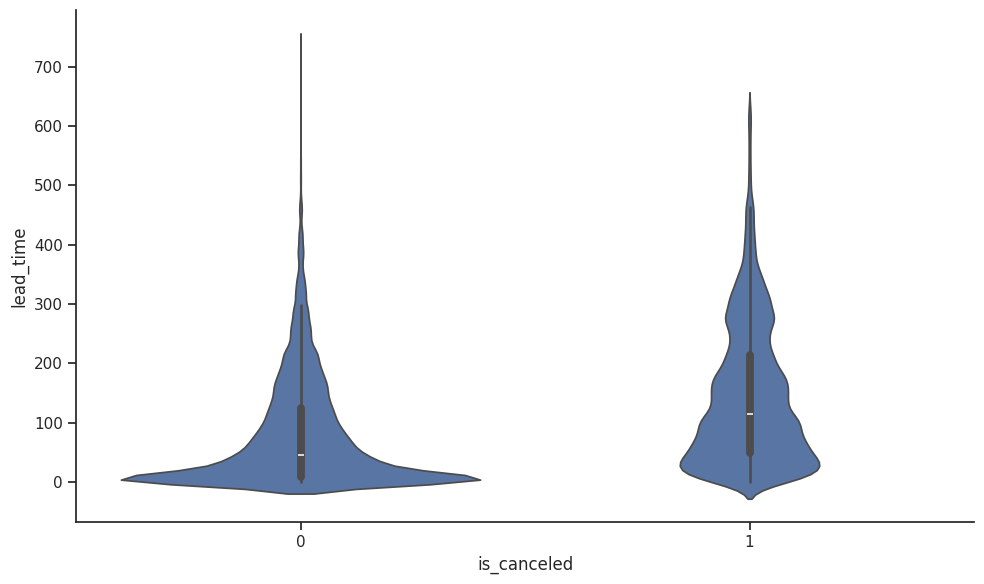

In [19]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='is_canceled', y='lead_time', data=data_clean)
sns.despine()
plt.tight_layout()
plt.show()

In [20]:
# отбор признаков
dataset = data_clean.drop(columns=['country', 'assigned_room_type',
                                   'arrival_date_month',
                                   'arrival_date_day_of_month', 'adults',
                                   'arrival_date_week_number',
                                   'arrival_date_year',
                                   'reservation_status',
                                   'reservation_status_date'])

In [21]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 117940 entries, 0 to 119389
Data columns (total 23 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           117940 non-null  object 
 1   is_canceled                     117940 non-null  int64  
 2   lead_time                       117940 non-null  int64  
 3   stays_in_weekend_nights         117940 non-null  int64  
 4   stays_in_week_nights            117940 non-null  int64  
 5   children                        117940 non-null  float64
 6   babies                          117940 non-null  int64  
 7   meal                            117940 non-null  object 
 8   market_segment                  117940 non-null  object 
 9   distribution_channel            117940 non-null  object 
 10  is_repeated_guest               117940 non-null  int64  
 11  previous_cancellations          117940 non-null  int64  
 12  previous_bookings_not

In [22]:
# кодирование категориальных признаков
categorical_cols = ['hotel', 'meal', 'market_segment', 'distribution_channel',
                    'deposit_type', 'customer_type', 'reserved_room_type']
df = dataset.copy()
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

In [23]:
df.corr()

,hotel,is_canceled,lead_time,stays_in_weekend_nights,stays_in_week_nights,children,babies,meal,market_segment,distribution_channel,...,reserved_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,total_people,month
hotel,1.000000,-0.139317,-0.075455,0.186050,0.234510,0.030388,0.048765,-0.012950,-0.086718,-0.175736,...,0.243915,0.074134,-0.157586,-0.072397,-0.047162,-0.148239,0.216929,0.039868,0.022478,-0.006600
is_canceled,-0.139317,1.000000,0.293466,-0.003011,0.024116,0.002970,-0.033568,-0.016950,0.057776,0.167410,...,-0.065533,-0.144500,0.471447,0.054708,-0.067565,0.053471,-0.193420,-0.233565,0.045375,0.011433
lead_time,-0.075455,0.293466,1.000000,0.085198,0.166639,-0.033999,-0.019790,0.001544,0.013012,0.220791,...,-0.103298,0.002961,0.375968,0.170183,0.073820,-0.059528,-0.116557,-0.095306,0.076945,0.132664
stays_in_weekend_nights,0.186050,-0.003011,0.085198,1.000000,0.493746,0.043258,0.022061,0.042672,0.116877,0.094710,...,0.142561,0.049552,-0.111417,-0.054253,-0.109940,0.049104,-0.019765,0.072892,0.112705,0.018308
stays_in_week_nights,0.234510,0.024116,0.166639,0.493746,1.000000,0.042130,0.024302,0.033150,0.110844,0.089651,...,0.171522,0.079649,-0.076482,-0.001627,-0.128642,0.066165,-0.026800,0.068493,0.114323,0.018940
children,0.030388,0.002970,-0.033999,0.043258,0.042130,1.000000,0.013984,-0.058205,0.089277,0.012993,...,0.345493,0.047874,-0.092962,-0.031996,-0.050757,0.290620,0.049389,0.082283,0.617910,0.001189
babies,0.048765,-0.033568,-0.019790,0.022061,0.024302,0.013984,1.000000,0.003277,-0.012562,-0.024983,...,0.034014,0.088270,-0.031970,-0.011116,-0.018125,0.026991,0.039295,0.106136,0.165240,0.012125
meal,-0.012950,-0.016950,0.001544,0.042672,0.033150,-0.058205,0.003277,1.000000,0.148978,0.121403,...,-0.131016,0.017220,-0.091005,-0.006934,0.044745,0.054707,-0.043365,0.021374,-0.006353,-0.016829
market_segment,-0.086718,0.057776,0.013012,0.116877,0.110844,0.089277,-0.012562,0.148978,1.000000,0.765430,...,0.097530,-0.070260,-0.186604,-0.041717,-0.167295,0.263253,-0.060991,0.277680,0.250695,0.001759
distribution_channel,-0.175736,0.167410,0.220791,0.094710,0.089651,0.012993,-0.024983,0.121403,0.765430,1.000000,...,-0.037108,-0.112016,0.091971,0.048742,-0.070571,0.115323,-0.131050,0.100757,0.177608,0.009131


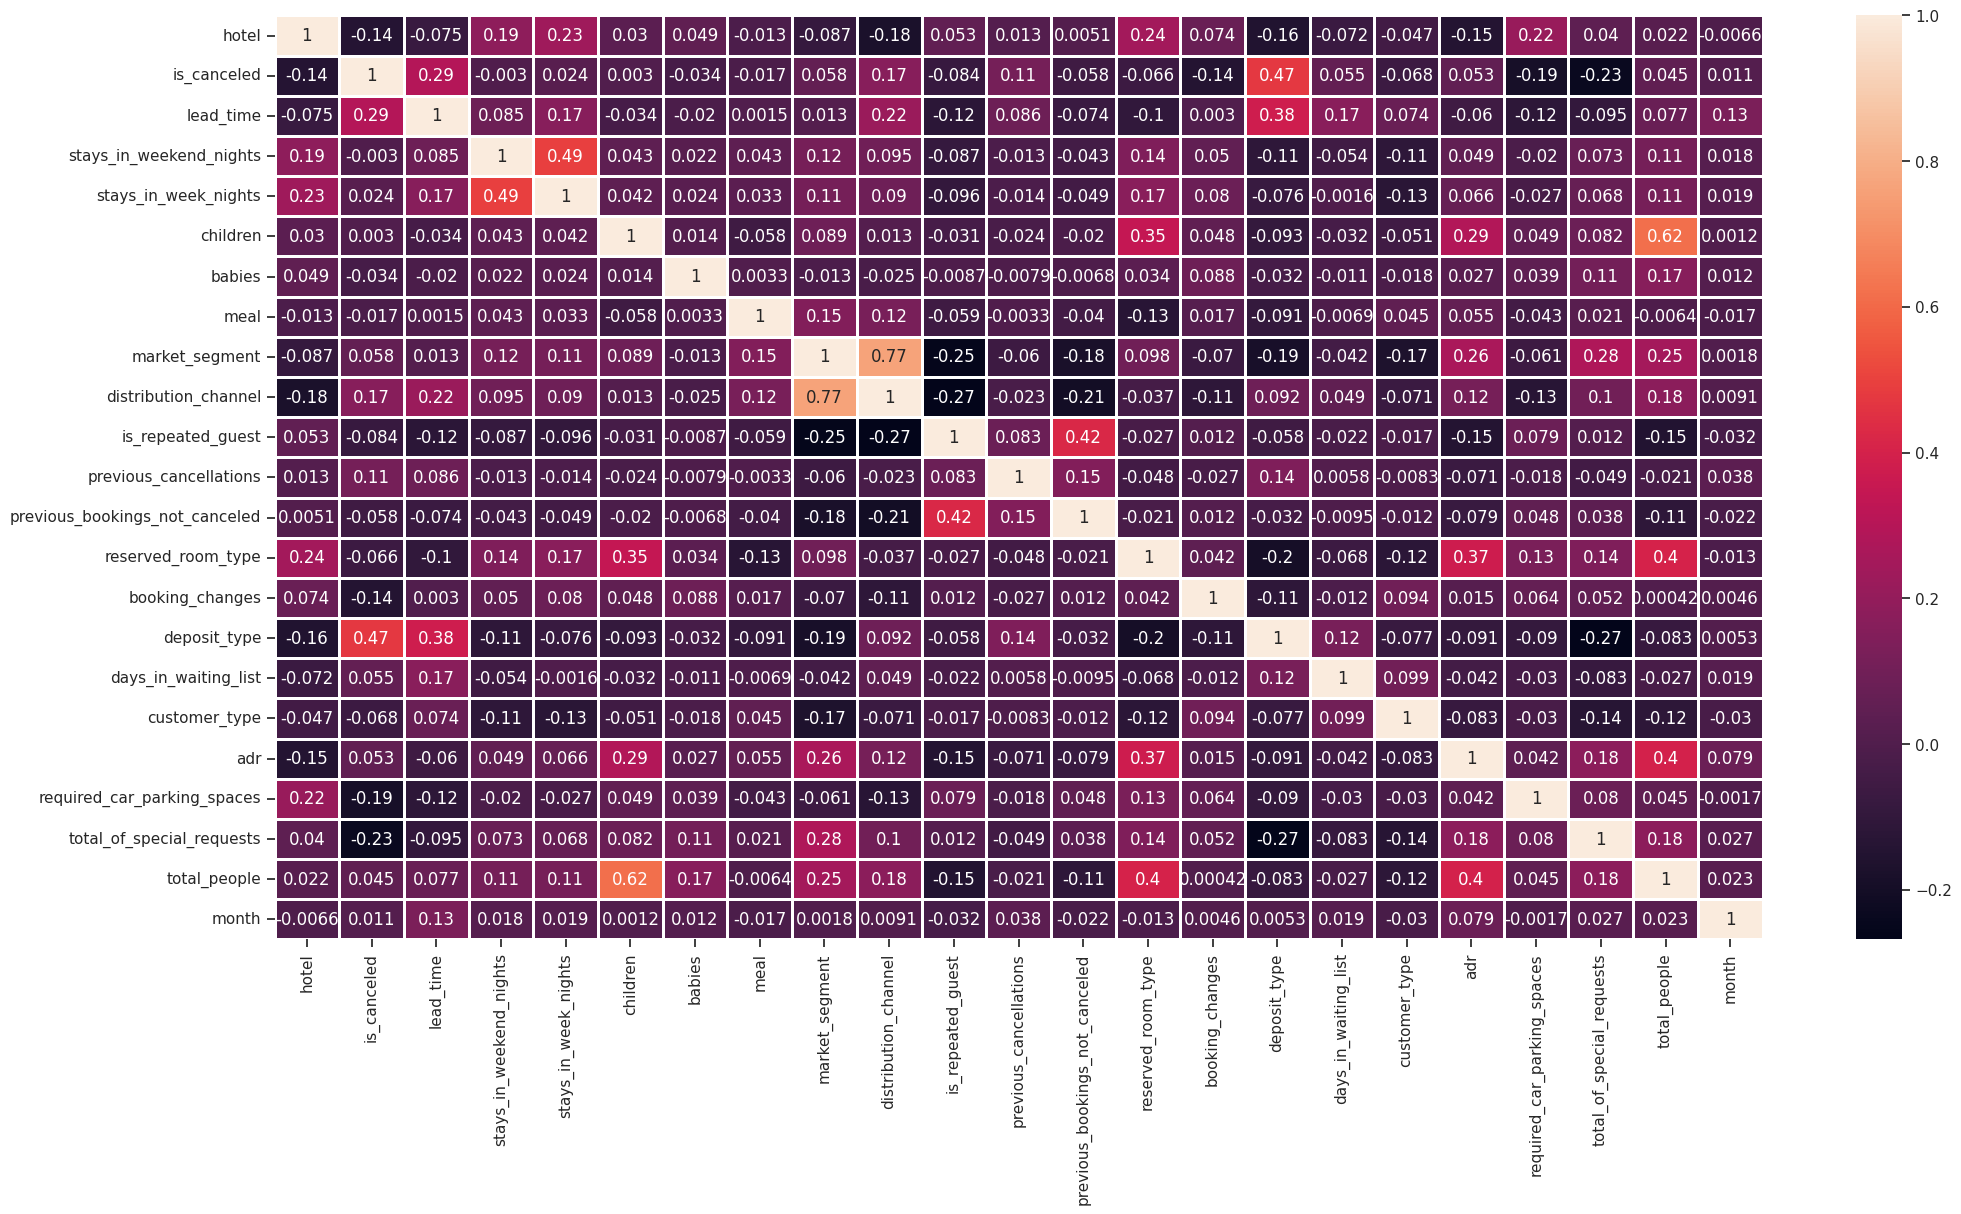

In [24]:
plt.figure(figsize = (24, 12))
sns.heatmap(df.corr(), annot = True, linewidths = 1)
plt.show()

In [25]:
df = df.drop(columns=['market_segment', 'customer_type',
                      'stays_in_weekend_nights'])

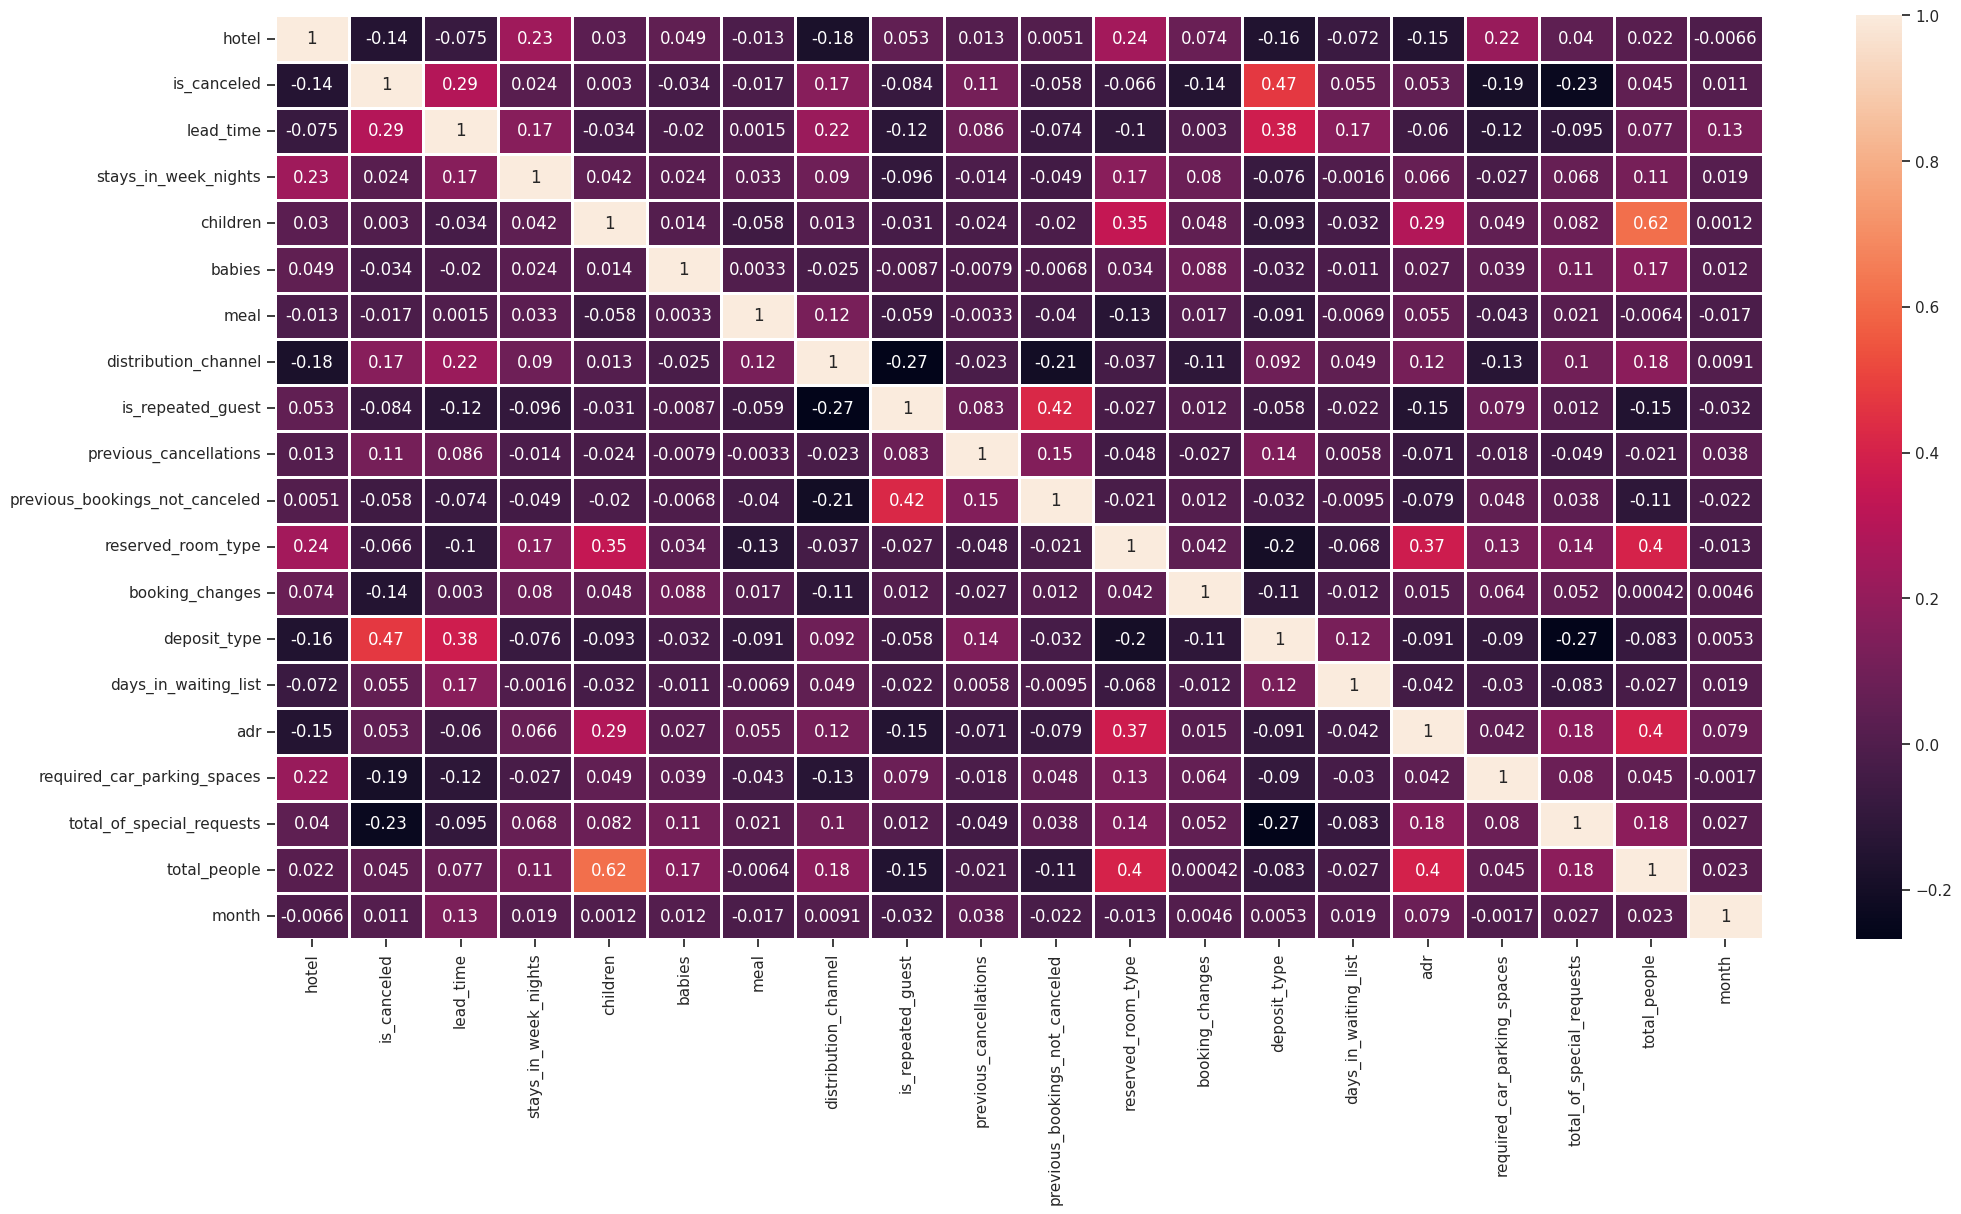

In [26]:
plt.figure(figsize = (24, 12))
sns.heatmap(df.corr(), annot = True, linewidths = 1)
plt.show()

In [27]:
# разделение на train/test выборки
X = df.drop('is_canceled', axis=1)
y = df['is_canceled']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [28]:
# стандартизация
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [29]:
model = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),

    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),

    layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
model.compile(optimizer='adam', loss='binary_crossentropy',
              metrics=['accuracy'])

In [31]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,129 (188.00 KB)

 Trainable params: 47,233 (184.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [32]:
history = model.fit(X_train, y_train,
                    epochs=100,
                    batch_size=128,
                    verbose=1,
                    validation_data=(X_test,y_test))

Epoch 1/100
738/738 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7850 - loss: 0.4483 - val_accuracy: 0.8046 - val_loss: 0.4154
Epoch 2/100
738/738 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7981 - loss: 0.4225 - val_accuracy: 0.8099 - val_loss: 0.4059
Epoch 3/100
738/738 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8032 - loss: 0.4136 - val_accuracy: 0.8114 - val_loss: 0.4000
Epoch 4/100
738/738 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8054 - loss: 0.4080 - val_accuracy: 0.8158 - val_loss: 0.3955
Epoch 5/100
738/738 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8081 - loss: 0.4028 - val_accuracy: 0.8162 - val_loss: 0.3934
Epoch 6/100
738/738 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8121 - loss: 0.3983 - val_accuracy: 0.8164 - val_loss: 0.3913
Epoch 7/100
738/738 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8124 - loss: 0.3958 - val_accuracy: 0.8231 - val_loss: 0.3824
Epoch 8/100
738/738 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8155 - loss: 0.3919 - val_accu

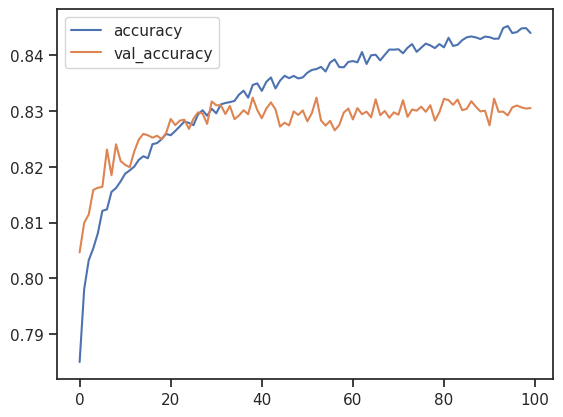

In [33]:
plt.plot(history.history['accuracy'],
         label='accuracy')
plt.plot(history.history['val_accuracy'],
         label='val_accuracy')
plt.legend()
plt.show()

In [34]:
y_pred = model.predict(X_test)

738/738 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [35]:
y_pred = (y_pred>0.5).astype('int64')
print(accuracy_score(y_test, y_pred))

0.8305070374766831


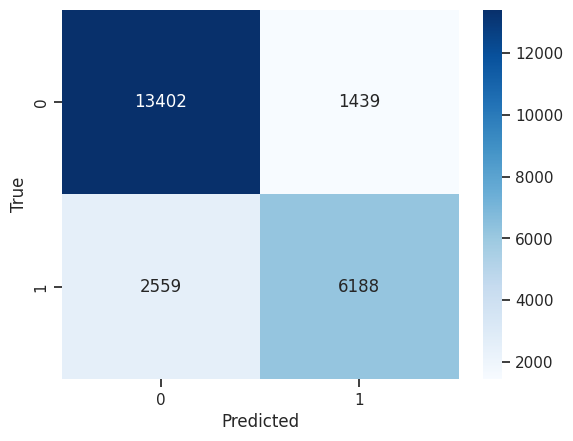

In [36]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()